# Day-1

In [1]:
# Import pandas library
# Used for data manipulation and analysis (DataFrame, CSV handling, etc.)
import pandas as pd

# Import seaborn library
# Used for statistical data visualization (better and more attractive graphs)
import seaborn as sns

# Import pyplot module from matplotlib
# Used for creating and customizing plots (titles, labels, show(), etc.)
import matplotlib.pyplot as plt

In [2]:
# Read data from a CSV file and store it in a DataFrame
df = pd.read_csv("sales_data.csv")

In [3]:
df

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717


In [4]:
# Group data by 'Product', calculate total Quantity for each product,
# and convert the result into a DataFrame
quan = df.groupby('Product')['Quantity'].sum().reset_index()

# Display the resulting DataFrame
quan

,Product,Quantity
0,Headphones,48
1,Laptop,136
2,Monitor,66
3,Phone,101
4,Tablet,127


Text(0.5, 1.0, 'Quantity Sold by Product')

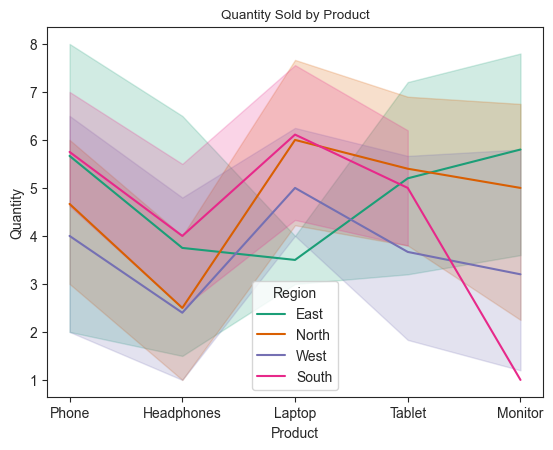

In [5]:
# Set the background style of the plot (ticks style shows axis lines clearly)
sns.set_style("ticks")

# Create a line plot
# x = Product (categorical axis)
# y = Quantity (values to plot)
# hue = Region (separate lines for each region)
# palette = "Dark2" (color scheme for different regions)
sns.lineplot(data=df, x="Product", y="Quantity", hue="Region", palette="Dark2")

# Set context to "paper" (smaller text, suitable for reports)
sns.set_context("paper")

# Add title to the plot
plt.title("Quantity Sold by Product")

# Day 2

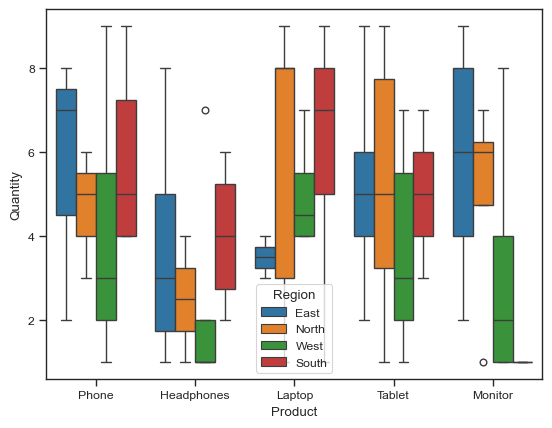

In [6]:
# Create a box plot to show distribution of Quantity
# x = Product (categories)
# y = Quantity (numerical values)
# hue = Region (separate boxes for each region)
sns.boxplot(data=df, x="Product", y="Quantity", hue="Region")

# Set context to "talk" (larger text, good for presentations)
sns.set_context("talk")

<Axes: xlabel='Product', ylabel='Quantity'>

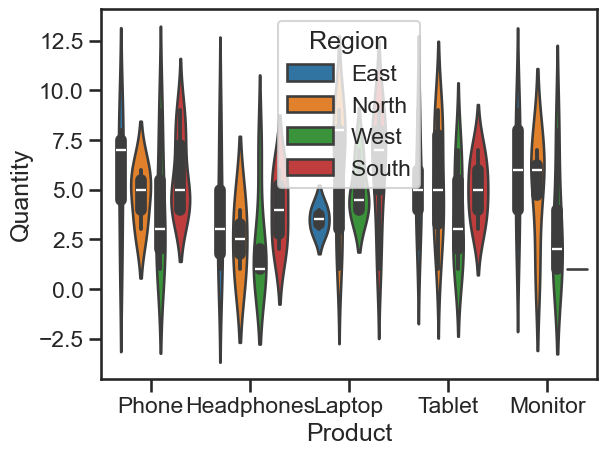

In [7]:
# Set context before plotting (larger text, good for presentations)
sns.set_context("talk")

# Create a violin plot to show distribution of Quantity
# x = Product (categories)
# y = Quantity (numerical values)
# hue = Region (separate distributions for each region)
sns.violinplot(data=df, x="Product", y="Quantity", hue="Region")

# Day-3

In [8]:
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [9]:
columns = ["Quantity","Total_Sales"]
# Select specific columns (Quantity and Total_Sales)
# and calculate the correlation between them
df[columns].corr()

,Quantity,Total_Sales
Quantity,1.000000,0.688107
Total_Sales,0.688107,1.000000


<Axes: >

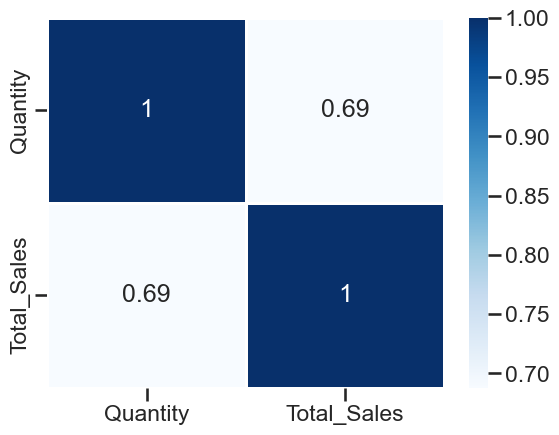

In [10]:
# Create a correlation matrix heatmap
# df[columns].corr() → computes correlation between Quantity and Total_Sales

# annot=True → shows correlation values inside the boxes
# cmap="Blues" → uses blue color gradient (light to dark)
# linewidths=2 → adds spacing (lines) between cells

sns.heatmap(data=df[columns].corr(), annot=True, cmap="Blues", linewidths=2)

# day-4

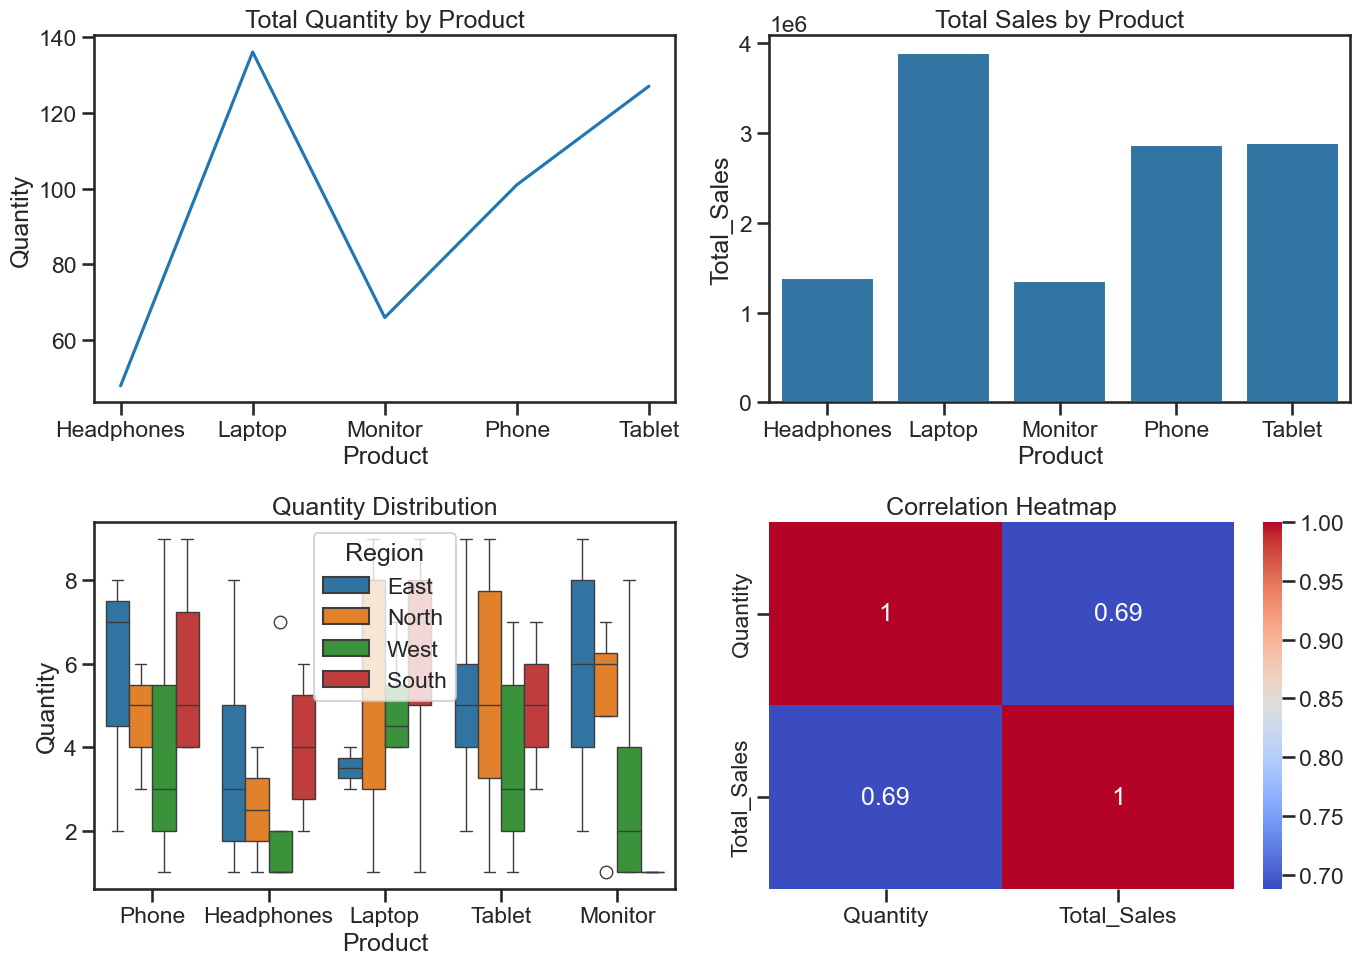

In [11]:
# Set overall theme for all plots (consistent styling)
sns.set_style("ticks")
sns.set_context("talk")

# Create a 2x2 subplot grid (4 plots in one figure)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------- Plot 1: Line Plot --------------------
# Total Quantity by Product
quan = df.groupby('Product')['Quantity'].sum().reset_index()

sns.lineplot(data=quan, x='Product', y='Quantity', ax=axes[0, 0])
axes[0, 0].set_title("Total Quantity by Product")

# -------------------- Plot 2: Bar Plot --------------------
# Total Sales by Product
sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

sns.barplot(data=sales, x='Product', y='Total_Sales', ax=axes[0, 1])
axes[0, 1].set_title("Total Sales by Product")

# -------------------- Plot 3: Box Plot --------------------
# Quantity distribution by Product & Region
sns.boxplot(data=df, x='Product', y='Quantity', hue='Region', ax=axes[1, 0])
axes[1, 0].set_title("Quantity Distribution")

# -------------------- Plot 4: Heatmap --------------------
# Correlation heatmap
columns = ["Quantity", "Total_Sales"]
sns.heatmap(df[columns].corr(), annot=True, cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show dashboard
plt.show()

# day-5

In [26]:
# Import Plotly Express module for quick and easy interactive visualizations
import plotly.express as px

# Group data by 'Product' and calculate total Quantity for each product
# reset_index() converts the result into a proper DataFrame
quan = df.groupby('Product')['Quantity'].sum().reset_index()

# Create an interactive bar chart
# x = Product (categories)
# y = Quantity (total values)
# title = chart title displayed on top
# Create an interactive bar chart using Plotly Express

fig = px.bar(
    quan,                      # DataFrame containing aggregated data
    x='Product',               # X-axis → Product categories
    y='Quantity',              # Y-axis → total quantity values
    
    hover_data=['Quantity'],   # Shows Quantity value when hovering on bars
    
    color='Quantity',          # Colors bars based on Quantity (gradient effect)
    
    title="Interactive Quantity Plot"  # Title of the chart
)

# Display the interactive plot
fig.show()

# day-6

In [19]:
# Import Plotly Graph Objects for detailed and customizable plots
import plotly.graph_objects as go

# Create an empty figure
fig = go.Figure()

# -------------------- Add Quantity Bar Plot --------------------
# x = Product categories
# y = Quantity values
# name = label shown in legend
fig.add_trace(go.Bar(
    x=df['Product'],
    y=df['Quantity'],
    name='Quantity'
))

# -------------------- Add Sales Bar Plot (Hidden Initially) --------------------
# visible=False → this plot is hidden at first
fig.add_trace(go.Bar(
    x=df['Product'],
    y=df['Total_Sales'],
    name='Sales',
    visible=False
))

# -------------------- Add Dropdown Menu --------------------
# Allows user to switch between Quantity and Sales
fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                # Button 1 → Show Quantity, hide Sales
                dict(
                    label="Quantity",
                    method="update",
                    args=[{"visible": [True, False]}]
                ),

                # Button 2 → Show Sales, hide Quantity
                dict(
                    label="Sales",
                    method="update",
                    args=[{"visible": [False, True]}]
                ),
            ]
        )
    ]
)

# Display the interactive chart
fig.show()

In [20]:
fig = px.bar(
    df,
    x="Product",
    y="Quantity",
    color="Region",
    animation_frame="Region",   # creates animation
    title="Animated Quantity by Region"
)

fig.show()

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------- Data Preparation --------------------
# Total Quantity per Product
quan = df.groupby('Product')['Quantity'].sum().reset_index()

# Total Sales per Product
sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

# -------------------- Create Subplots Layout --------------------
# 2x2 Dashboard layout
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Quantity by Product",
        "Sales by Product",
        "Quantity Distribution",
        "Correlation Heatmap"
    )
)

# -------------------- Plot 1: Bar (Quantity) --------------------
fig.add_trace(
    go.Bar(x=quan['Product'], y=quan['Quantity'], name="Quantity"),
    row=1, col=1
)

# -------------------- Plot 2: Bar (Sales) --------------------
fig.add_trace(
    go.Bar(x=sales['Product'], y=sales['Total_Sales'], name="Sales"),
    row=1, col=2
)

# -------------------- Plot 3: Box Plot --------------------
fig.add_trace(
    go.Box(
        x=df['Product'],
        y=df['Quantity'],
        name="Distribution"
    ),
    row=2, col=1
)

# -------------------- Plot 4: Heatmap --------------------
corr = df[['Quantity', 'Total_Sales']].corr()

fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale='Blues'
    ),
    row=2, col=2
)

# -------------------- Layout Settings --------------------
fig.update_layout(
    title="Sales Dashboard",
    height=800,
    showlegend=True
)

# Show dashboard
fig.show()